필터링 전 단백질 개수: 5626
엄격한 dropna 적용 시 개수: 1182
그룹별 Valid Value 필터링 후 개수: 4050
=== Imputation 결과 확인 ===
Imputation 전 전체 결측치 개수: 14949 개
Imputation 후 전체 결측치 개수: 0 개


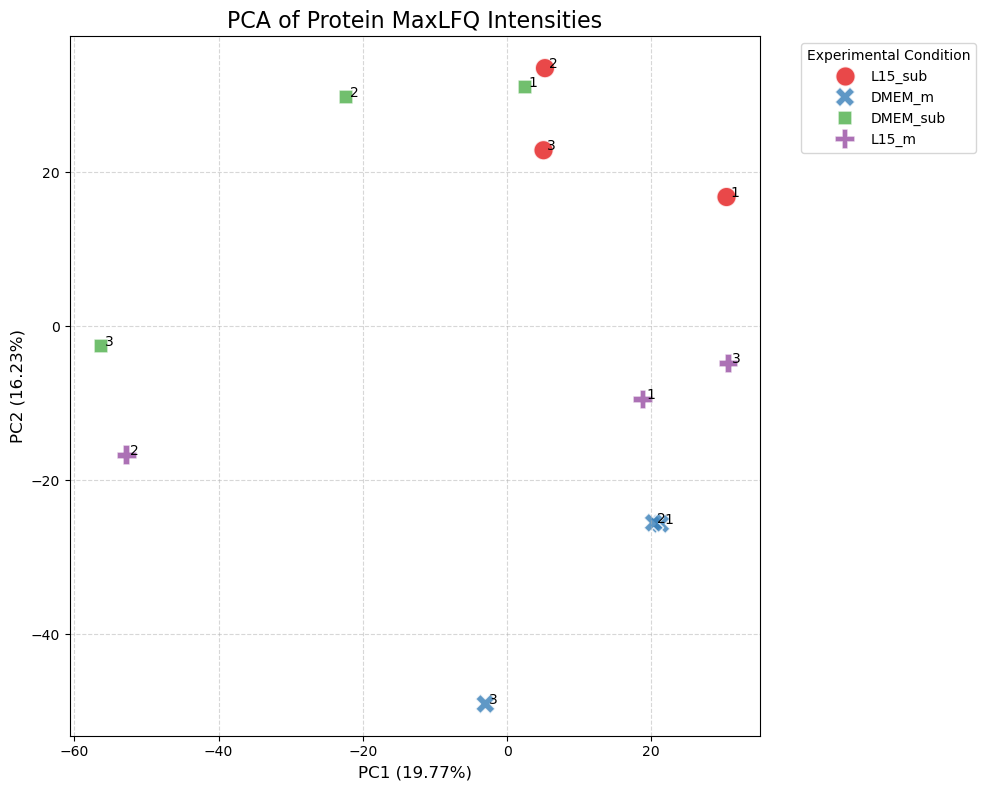

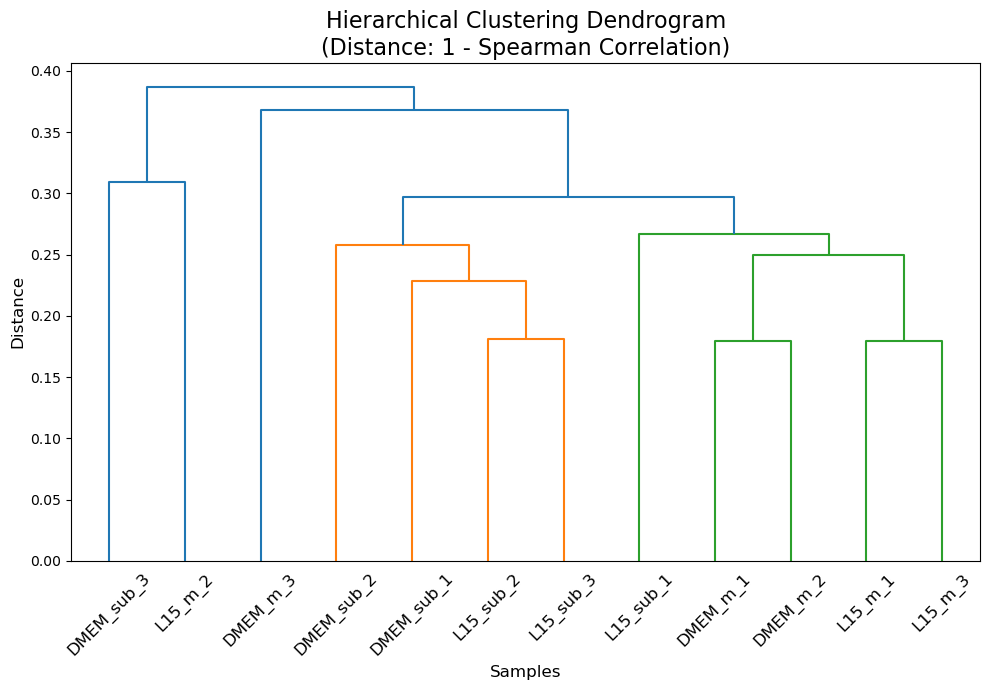

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# ==========================================
# 1. 데이터 불러오기 및 전처리
# ==========================================
file_path = 'combined_protein.tsv'
df = pd.read_csv(file_path, sep='\t')

# Contaminant 및 Decoy 제거 (파일 포맷에 맞게 수정 필요)
df = df[~df['Protein'].str.startswith('contam_', na=False)]
df = df[~df['Protein'].str.startswith('rev_', na=False)]
df.set_index('Protein', inplace=True)

# MaxLFQ 컬럼 추출
lfq_cols = [col for col in df.columns if 'MaxLFQ Intensity' in col]
data = df[lfq_cols].copy()

# ==========================================
# 2. 샘플 이름 변경 및 그룹 생성
# ==========================================
new_cols = {}
for col in lfq_cols:
    # " MaxLFQ Intensity" 텍스트 제거 -> "10_L15_sub_1_1"
    clean_name = col.replace(" MaxLFQ Intensity", "").strip()
    parts = clean_name.split('_')
    
    # parts[1]: media, parts[2]: 실험방식(m/M/sub), parts[3]: 첫번째 replicate 숫자
    # 실험방식을 소문자로 통일하여 (M -> m) 일관성 유지
    new_name = f"{parts[1]}_{parts[2].lower()}_{parts[3]}"
    new_cols[col] = new_name

# 컬럼명 덮어쓰기 (예: L15_sub_1, DMEM_m_1)
data.rename(columns=new_cols, inplace=True)

# Log2 변환 및 결측치 제거
data.replace(0, np.nan, inplace=True)
data_log2 = np.log2(data)
#data_clean = data_log2.dropna() # 결측치가 하나라도 있는 단백질 제외


# 그룹 이름 정의 (샘플 컬럼명 규칙에 맞게)
groups = ['DMEM_m', 'DMEM_sub', 'L15_m', 'L15_sub']

# 각 그룹별로 유효한 값(NaN이 아닌 값)이 몇 개인지 계산할 빈 데이터프레임 생성
valid_counts = pd.DataFrame(index=data_log2.index)

for group in groups:
    # 해당 그룹에 속하는 컬럼들만 추출 (예: DMEM_m_1, DMEM_m_2, DMEM_m_3)
    group_cols = [col for col in data_log2.columns if col.startswith(group)]
    
    # 해당 그룹 내에서 NaN이 아닌(notna) 값의 개수를 셈
    valid_counts[group] = data_log2[group_cols].notna().sum(axis=1)

# "최소 한 그룹"에서 "2개 이상(3개 rep 기준)" 유효한 값을 가지는 단백질을 True로 판별 (Masking)
# 3개 중 2개 이상이면 통계 분석(t-test 등)을 할 수 있는 최소한의 조건이 됩니다.
min_reps = 2
mask = (valid_counts >= min_reps).any(axis=1)




# 필터링 적용
data_filtered = data_log2[mask]





print(f"필터링 전 단백질 개수: {data_log2.shape[0]}")
print(f"엄격한 dropna 적용 시 개수: {data_log2.dropna().shape[0]}")
print(f"그룹별 Valid Value 필터링 후 개수: {data_filtered.shape[0]}")




#Imputation 

import numpy as np
import pandas as pd

# ==========================================
# Perseus 스타일 결측치 대체 (Missing Value Imputation)
# ==========================================

def impute_missing_values(df, width=0.3, downshift=1.8):
    """
    각 샘플별로 검출된 단백질들의 정규분포를 기준으로,
    평균에서 왼쪽(값이 작은 쪽)으로 이동(downshift)시킨 좁은(width) 정규분포를 임의로 만들어
    결측치를 대체하는 함수입니다.
    """
    imputed_df = df.copy()
    
    # 각 샘플(컬럼)별로 반복
    for col in imputed_df.columns:
        # 1. 해당 샘플에 존재하는 유효한 값들의 평균과 표준편차 계산
        valid_values = imputed_df[col].dropna()
        mean_val = valid_values.mean()
        std_val = valid_values.std()
        
        # 2. 결측치를 채울 새로운 가상의 분포(LOD 근처의 낮은 값) 파라미터 계산
        # 보통 원래 평균에서 1.8 표준편차만큼 값을 낮추고, 분포의 폭은 0.3배로 좁힙니다.
        shift_mean = mean_val - (downshift * std_val)
        shift_std = std_val * width
        
        # 3. 해당 샘플의 결측치(NaN) 개수 파악
        null_count = imputed_df[col].isna().sum()
        
        if null_count > 0:
            # 4. 새로 만든 분포에서 결측치 개수만큼 난수(Random numbers) 추출
            # 시드(seed)를 고정하지 않으면 실행할 때마다 값이 미세하게 바뀔 수 있습니다.
            random_values = np.random.normal(loc=shift_mean, scale=shift_std, size=null_count)
            
            # 5. 빈칸에 난수 채워넣기
            imputed_df.loc[imputed_df[col].isna(), col] = random_values
            
    return imputed_df

# 앞서 필터링을 마친 data_filtered에 Imputation 적용
data_imputed = impute_missing_values(data_filtered)

# 확인
print("=== Imputation 결과 확인 ===")
print(f"Imputation 전 전체 결측치 개수: {data_filtered.isna().sum().sum()} 개")
print(f"Imputation 후 전체 결측치 개수: {data_imputed.isna().sum().sum()} 개")

# 이후 데이터 확인을 위해 첫 5줄 출력
# print(data_imputed.head())


# ==========================================
# 3. PCA (주성분 분석) - 색상 그룹화
# ==========================================
data_transposed = data_imputed.T

# 샘플 이름에서 마지막 '_숫자'를 제외하여 Condition 그룹 생성 (예: L15_sub, DMEM_m)
conditions = [name.rsplit('_', 1)[0] for name in data_transposed.index]

# 정규화 및 PCA
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_transposed)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_scaled)

# PCA 데이터프레임
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Sample'] = data_transposed.index
pca_df['Condition'] = conditions # 그룹 정보 추가

explained_variance = pca.explained_variance_ratio_ * 100

# PCA 시각화
plt.figure(figsize=(10, 8))
# hue='Condition'을 통해 4가지 실험군별로 색상을 다르게 지정
sns.scatterplot(x='PC1', y='PC2', hue='Condition', style='Condition', 
                data=pca_df, s=200, palette='Set1', alpha=0.8)

# 각 점 옆에 샘플 이름(replicate 번호) 텍스트 추가
for i in range(pca_df.shape[0]):
    plt.text(pca_df.PC1[i] + 0.5, pca_df.PC2[i], 
             pca_df.Sample[i].split('_')[-1], # 숫자만 표시
             horizontalalignment='left', size='medium', color='black')

plt.title('PCA of Protein MaxLFQ Intensities', fontsize=16)
plt.xlabel(f'PC1 ({explained_variance[0]:.2f}%)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}%)', fontsize=12)
plt.legend(title='Experimental Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('PCA_grouped_plot.png', dpi=300)
# plt.show()

# ==========================================
# 4. H-Clustering (Dendrogram with Spearman)
# ==========================================
plt.figure(figsize=(10, 7))

# 1. 샘플 간의 Spearman 상관계수 매트릭스 계산
corr_matrix = data_imputed.corr(method='spearman')

# 2. 상관계수를 거리 지표로 변환 (거리가 가까울수록 = 상관계수가 높을수록)
# Distance = 1 - Correlation
dist_matrix = 1 - corr_matrix

# 3. 1D condensed distance matrix로 변환 (scipy linkage 함수 규칙)
condensed_dist = squareform(dist_matrix)

# 4. 계층적 군집화 수행 (평균 연결법 사용)
Z = sch.linkage(condensed_dist, method='average')

# 5. 덴드로그램 그리기
sch.dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=45, leaf_font_size=12)

plt.title('Hierarchical Clustering Dendrogram\n(Distance: 1 - Spearman Correlation)', fontsize=16)
plt.ylabel('Distance', fontsize=12)
plt.xlabel('Samples', fontsize=12)
plt.tight_layout()
plt.savefig('Dendrogram_spearman.png', dpi=300)
# plt.show()

Drawing dendrogram for DMEM...
Drawing dendrogram for L-15...


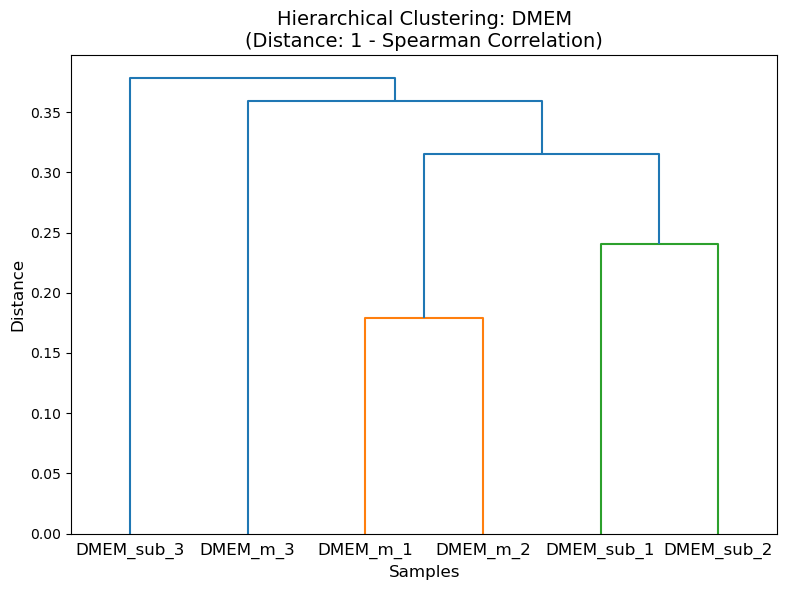

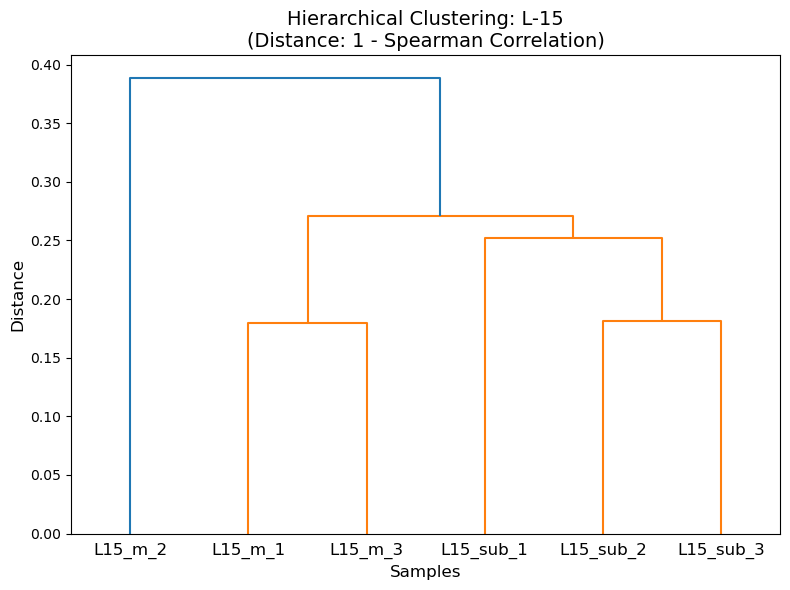

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# ==========================================
# 5. Media 별 H-Clustering (Spearman)
# ==========================================

# 덴드로그램을 그리는 함수 정의 (반복 사용을 위해)
def plot_media_dendrogram(df_subset, media_name):
    plt.figure(figsize=(8, 6))
    
    # 1. 샘플 간의 Spearman 상관계수 계산
    corr_matrix = df_subset.corr(method='spearman')
    
    # 2. 거리 매트릭스 변환 (1 - 상관계수)
    dist_matrix = 1 - corr_matrix
    
    # 3. Condensed distance matrix 변환
    condensed_dist = squareform(dist_matrix)
    
    # 4. 계층적 군집화 (평균 연결법)
    Z = sch.linkage(condensed_dist, method='average')
    
    # 5. 덴드로그램 시각화
    sch.dendrogram(Z, labels=corr_matrix.columns, leaf_rotation=0, leaf_font_size=12)
    
    plt.title(f'Hierarchical Clustering: {media_name}\n(Distance: 1 - Spearman Correlation)', fontsize=14)
    plt.ylabel('Distance', fontsize=12)
    plt.xlabel('Samples', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'Dendrogram_{media_name}_imputed.png', dpi=300)
    # plt.show() # 주피터 환경일 경우 주석 해제

# 데이터프레임에서 Media 별로 컬럼 분리
# (이전 코드에서 컬럼명을 'DMEM_m_1', 'L15_sub_1' 등으로 변경해둔 상태를 가정합니다)
dmem_cols = [col for col in data_imputed.columns if 'DMEM' in col.upper()]
l15_cols = [col for col in data_imputed.columns if 'L15' in col.upper()]

data_dmem = data_imputed[dmem_cols]
data_l15 = data_imputed[l15_cols]

# 함수 호출하여 각각의 덴드로그램 생성 및 저장
print("Drawing dendrogram for DMEM...")
plot_media_dendrogram(data_dmem, 'DMEM')

print("Drawing dendrogram for L-15...")
plot_media_dendrogram(data_l15, 'L-15')

In [ ]:
#Imputation 

import numpy as np
import pandas as pd

# ==========================================
# Perseus 스타일 결측치 대체 (Missing Value Imputation)
# ==========================================

def impute_missing_values(df, width=0.3, downshift=1.8):
    """
    각 샘플별로 검출된 단백질들의 정규분포를 기준으로,
    평균에서 왼쪽(값이 작은 쪽)으로 이동(downshift)시킨 좁은(width) 정규분포를 임의로 만들어
    결측치를 대체하는 함수입니다.
    """
    imputed_df = df.copy()
    
    # 각 샘플(컬럼)별로 반복
    for col in imputed_df.columns:
        # 1. 해당 샘플에 존재하는 유효한 값들의 평균과 표준편차 계산
        valid_values = imputed_df[col].dropna()
        mean_val = valid_values.mean()
        std_val = valid_values.std()
        
        # 2. 결측치를 채울 새로운 가상의 분포(LOD 근처의 낮은 값) 파라미터 계산
        # 보통 원래 평균에서 1.8 표준편차만큼 값을 낮추고, 분포의 폭은 0.3배로 좁힙니다.
        shift_mean = mean_val - (downshift * std_val)
        shift_std = std_val * width
        
        # 3. 해당 샘플의 결측치(NaN) 개수 파악
        null_count = imputed_df[col].isna().sum()
        
        if null_count > 0:
            # 4. 새로 만든 분포에서 결측치 개수만큼 난수(Random numbers) 추출
            # 시드(seed)를 고정하지 않으면 실행할 때마다 값이 미세하게 바뀔 수 있습니다.
            random_values = np.random.normal(loc=shift_mean, scale=shift_std, size=null_count)
            
            # 5. 빈칸에 난수 채워넣기
            imputed_df.loc[imputed_df[col].isna(), col] = random_values
            
    return imputed_df

# 앞서 필터링을 마친 data_filtered에 Imputation 적용
data_imputed = impute_missing_values(data_filtered)

# 확인
print("=== Imputation 결과 확인 ===")
print(f"Imputation 전 전체 결측치 개수: {data_filtered.isna().sum().sum()} 개")
print(f"Imputation 후 전체 결측치 개수: {data_imputed.isna().sum().sum()} 개")

# 이후 데이터 확인을 위해 첫 5줄 출력
# print(data_imputed.head())

/tmp/ipykernel_74638/2392223922.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_74638/2392223922.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


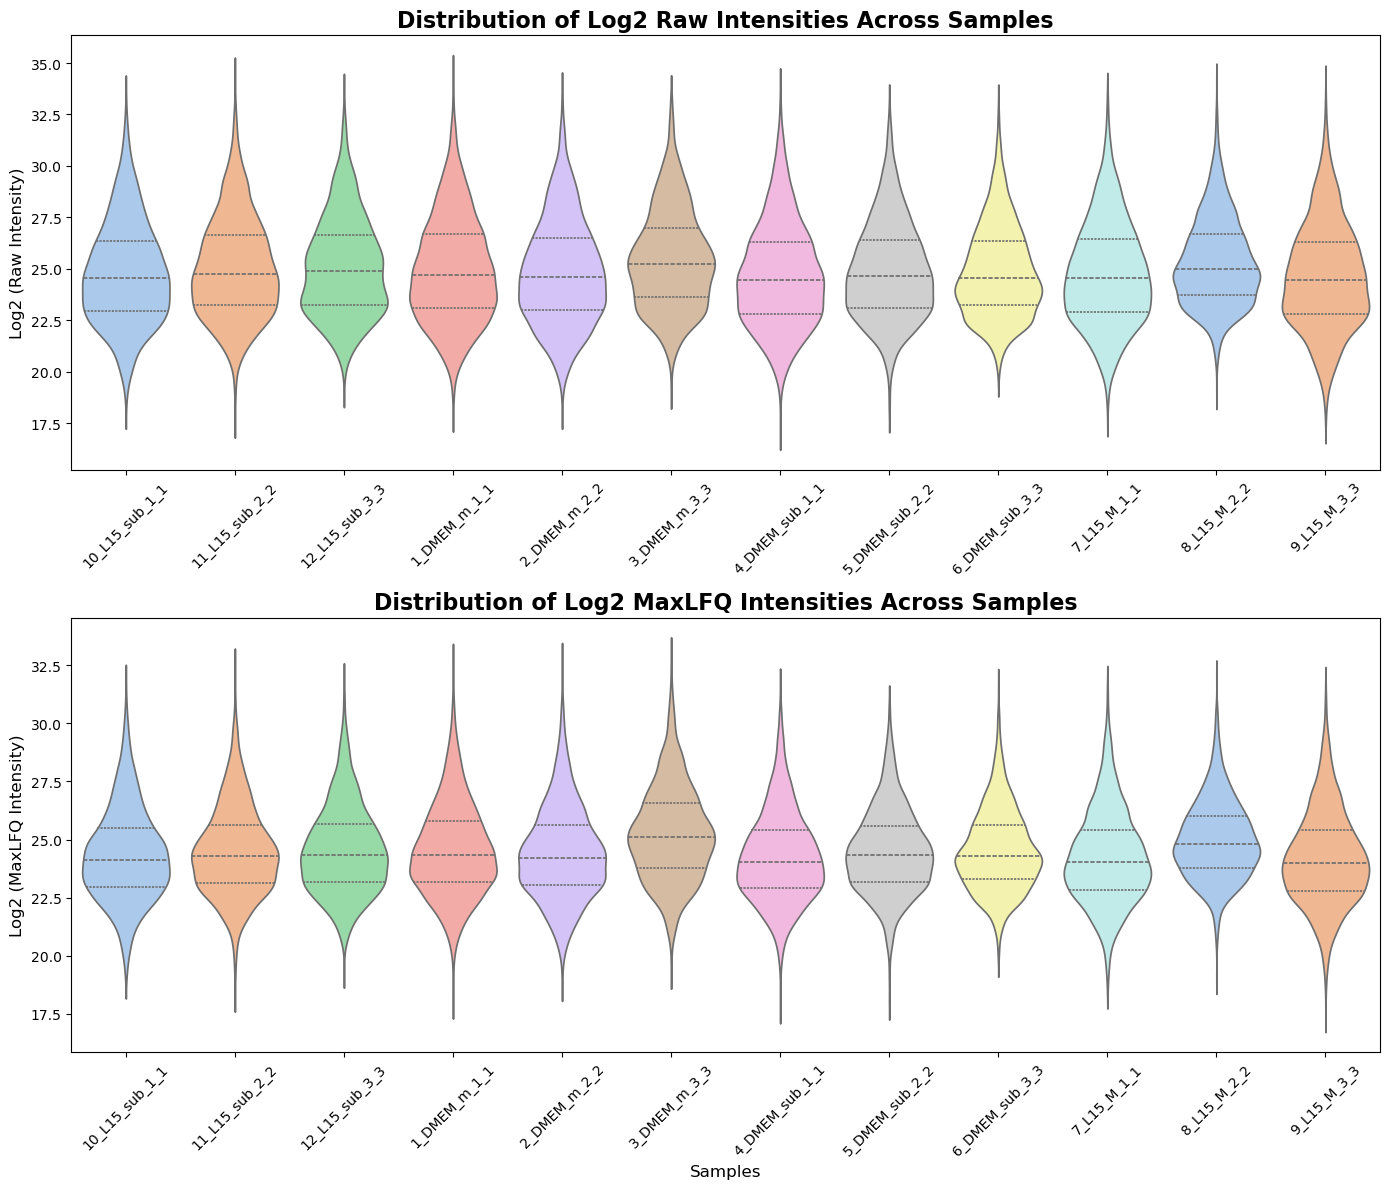

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 데이터 불러오기 및 전처리
# ==========================================
# MS Fragger 결과 파일 로드
file_path = './combined_protein.tsv'
df = pd.read_csv(file_path, sep='\t')

# 오염물질 및 Decoy 단백질 제거 (필요에 따라 컬럼명 수정)
df = df[~df['Protein'].astype(str).str.startswith('contam_')]
df = df[~df['Protein'].astype(str).str.startswith('rev_')]

# ==========================================
# 2. 컬럼 분류 (Raw Intensity vs MaxLFQ Intensity)
# ==========================================
# 주의: MS Fragger/IonQuant 결과 파일의 실제 컬럼명 패턴에 맞게 조정이 필요할 수 있습니다.
# 일반적으로 MaxLFQ가 포함된 컬럼과 그렇지 않은 일반 Intensity 컬럼을 구분합니다.

lfq_cols = [col for col in df.columns if 'MaxLFQ' in col]
# Raw Intensity는 'Intensity'라는 단어는 있지만 'MaxLFQ'는 없는 컬럼으로 추출
raw_cols = [col for col in df.columns if 'Intensity' in col and 'MaxLFQ' not in col]

# ==========================================
# 3. 데이터 변환 (Log2 스케일링 및 Reshaping)
# ==========================================
# 단백질 발현량이 0인 경우 결측치(NaN)로 처리 후 Log2 변환
raw_data = df[raw_cols].replace(0, np.nan).apply(np.log2)
lfq_data = df[lfq_cols].replace(0, np.nan).apply(np.log2)

# 컬럼명에서 불필요한 공통 단어(예: ' Intensity', ' MaxLFQ Intensity')를 지워주면 그래프 X축이 깔끔해집니다.
raw_data.columns = [col.replace(' Intensity', '').strip() for col in raw_data.columns]
lfq_data.columns = [col.replace(' MaxLFQ', '').replace(' Intensity', '').strip() for col in lfq_data.columns]

# Seaborn에서 바이올린 플롯을 그리기 위해 데이터를 긴 형태(Long format)로 변환 (Melt)
raw_melted = raw_data.melt(var_name='Sample', value_name='Log2 Raw Intensity').dropna()
lfq_melted = lfq_data.melt(var_name='Sample', value_name='Log2 MaxLFQ Intensity').dropna()

# ==========================================
# 4. Violin Plot 시각화
# ==========================================
# 2개의 그래프를 위아래로 배치
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# 첫 번째 그래프: Raw Intensity
sns.violinplot(
    data=raw_melted, 
    x='Sample', 
    y='Log2 Raw Intensity', 
    ax=axes[0], 
    palette='pastel', 
    inner='quartile' # 바이올린 안에 사분위수(25%, 50%, 75%) 표시
)
axes[0].set_title('Distribution of Log2 Raw Intensities Across Samples', fontsize=16, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Log2 (Raw Intensity)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# 두 번째 그래프: MaxLFQ Intensity
sns.violinplot(
    data=lfq_melted, 
    x='Sample', 
    y='Log2 MaxLFQ Intensity', 
    ax=axes[1], 
    palette='pastel', 
    inner='quartile'
)
axes[1].set_title('Distribution of Log2 MaxLFQ Intensities Across Samples', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Samples', fontsize=12)
axes[1].set_ylabel('Log2 (MaxLFQ Intensity)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# 그래프 간격 조정 및 저장
plt.tight_layout()
plt.savefig('Intensity_Violin_Plots.png', dpi=300, bbox_inches='tight')
# plt.show() # 주피터 환경일 경우 주석 해제하여 확인

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ==========================================
# 통계 분석 및 Volcano Plot 생성 함수 정의
# ==========================================
def analyze_and_plot_volcano(df, g1_cols, g2_cols, drop_sample=None):
    # 1. 샘플 제외 로직 적용
    current_g1 = [col for col in g1_cols if col != drop_sample]
    current_g2 = [col for col in g2_cols if col != drop_sample]
    
    # 제외된 샘플 이름 설정 (그래프 제목용)
    title_suffix = f"(Dropped: {drop_sample})" if drop_sample else "(All Samples Included)"
    
    # 2. 통계 값 계산 (Log2 Fold Change)
    # df는 이미 log2 변환된 데이터이므로 단순히 평균의 차이를 구하면 Log2FC가 됩니다.
    mean_g1 = df[current_g1].mean(axis=1)
    mean_g2 = df[current_g2].mean(axis=1)
    log2fc = mean_g1 - mean_g2
    
    # 3. p-value 계산 (Independent t-test)
    # scipy의 ttest_ind를 사용해 전체 행에 대해 한 번에 계산
    t_stat, p_values = stats.ttest_ind(df[current_g1], df[current_g2], axis=1, nan_policy='omit')
    
    # p-value가 0이 나와 -log10 계산 시 무한대가 되는 것을 방지
    p_values = np.where(p_values == 0, 1e-300, p_values) 
    neg_log10_p = -np.log10(p_values)
    
    # (선택) FDR (q-value) 계산 - 다중검정 보정
    # 유의미한 p-value에 대해서만 FDR을 계산하기 위해 결측치 제외
    valid_idx = ~np.isnan(p_values)
    q_values = np.full(p_values.shape, np.nan)
    if valid_idx.sum() > 0:
        _, q_values[valid_idx], _, _ = multipletests(p_values[valid_idx], method='fdr_bh')
    
    # 결과 데이터프레임 생성
    res_df = pd.DataFrame({
        'Log2FC': log2fc,
        'p_value': p_values,
        '-Log10(p)': neg_log10_p,
        'FDR': q_values
    }, index=df.index)
    
    # 4. Volcano Plot 시각화 설정
    plt.figure(figsize=(8, 6))
    
    # 유의성 기준 설정: p-value < 0.05 이고, |Log2FC| > 1 (2배 이상 변화)
    p_threshold = -np.log10(0.05)
    fc_threshold = 1.0
    
    # 색상 부여를 위한 조건 마스크
    sig_up = (res_df['Log2FC'] >= fc_threshold) & (res_df['-Log10(p)'] >= p_threshold)
    sig_down = (res_df['Log2FC'] <= -fc_threshold) & (res_df['-Log10(p)'] >= p_threshold)
    non_sig = ~(sig_up | sig_down)
    
    # 산점도 그리기
    plt.scatter(res_df.loc[non_sig, 'Log2FC'], res_df.loc[non_sig, '-Log10(p)'], 
                color='grey', alpha=0.5, s=20, label='Not Sig')
    plt.scatter(res_df.loc[sig_up, 'Log2FC'], res_df.loc[sig_up, '-Log10(p)'], 
                color='red', alpha=0.7, s=30, label='Up-regulated')
    plt.scatter(res_df.loc[sig_down, 'Log2FC'], res_df.loc[sig_down, '-Log10(p)'], 
                color='blue', alpha=0.7, s=30, label='Down-regulated')
    
    # 기준선 (Threshold lines) 추가
    plt.axhline(y=p_threshold, color='black', linestyle='--', linewidth=1)
    plt.axvline(x=fc_threshold, color='black', linestyle='--', linewidth=1)
    plt.axvline(x=-fc_threshold, color='black', linestyle='--', linewidth=1)
    
    # 그래프 꾸미기
    plt.title(f'DMEM: Subculture vs Maintain\n{title_suffix}', fontsize=14)
    plt.xlabel('Log2 Fold Change (Subculture / Maintain)', fontsize=12)
    plt.ylabel('-Log10 (p-value)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # 이미지 저장
    safe_name = drop_sample if drop_sample else "None"
    plt.savefig(f'Volcano_DMEM_drop_{safe_name}.png', dpi=300)
    plt.close() # 여러 개를 그릴 것이므로 화면에 띄우지 않고 닫음
    
    return res_df

# ==========================================
# 실행 로직 (반복문)
# ==========================================
# 비교할 두 그룹 컬럼 정의
group_sub = [col for col in data_imputed.columns if col.startswith('DMEM_sub')]
group_m = [col for col in data_imputed.columns if col.startswith('DMEM_m')]

all_target_samples = group_sub + group_m

print("Volcano Plot 생성을 시작합니다...")

# 1. 샘플을 0개 제외 (모든 샘플 사용)
print("1. 전체 샘플(0개 제외) 분석 중...")
res_all = analyze_and_plot_volcano(data_imputed, group_sub, group_m, drop_sample=None)

# 2. 샘플을 제외 분석
sample_to_drop = ['DMEM_sub_3', 'DMEM_m_3']
print(f"-> '{sample_to_drop}' 샘플 제외 분석 중...")
analyze_and_plot_volcano(data_imputed, group_sub, group_m, drop_sample=sample_to_drop)

print("모든 Volcano Plot 생성이 완료되었습니다. 폴더를 확인해주세요.")

Volcano Plot 생성을 시작합니다...
1. 전체 샘플(0개 제외) 분석 중...
-> '['DMEM_sub_3', 'DMEM_m_3', 'L15_m_2']' 샘플 제외 분석 중...
모든 Volcano Plot 생성이 완료되었습니다. 폴더를 확인해주세요.


In [ ]:
 'L15_m_2'

group_sub = [col for col in data_imputed.columns if col.startswith('L15_sub')]
group_m = [col for col in data_imputed.columns if col.startswith('L15_m')]